# Import libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("/Users/ekaterinasorokopudova/Desktop/Tareas repository/Sprint 13/data/df_with_fulltext_embedding.csv")

In [11]:
def fix_emb(x):
    if isinstance(x, str):
        x = x.strip("[]")
        arr = np.array([float(a) for a in x.split()])
        return arr
    return np.array(x)

In [12]:
df["embedding"] = df["embedding"].apply(fix_emb)

X = np.vstack(df["embedding"].values)
y = df["queue"]


# Train/test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression

In [14]:
clf = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    solver="lbfgs"
)

clf.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'multinomial'


In [15]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.62      0.70       558
               Customer Service       0.33      0.34      0.33       854
                General Inquiry       0.00      0.00      0.00        81
                Human Resources       0.89      0.07      0.13       115
                     IT Support       0.36      0.13      0.19       687
                Product Support       0.35      0.31      0.33      1050
          Returns and Exchanges       0.60      0.05      0.10       287
            Sales and Pre-Sales       0.53      0.05      0.10       184
Service Outages and Maintenance       0.72      0.45      0.55       230
              Technical Support       0.42      0.78      0.55      1672

                       accuracy                           0.43      5718
                      macro avg       0.50      0.28      0.30      5718
                   weighted avg       0.45      0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

# Confusion Matrix

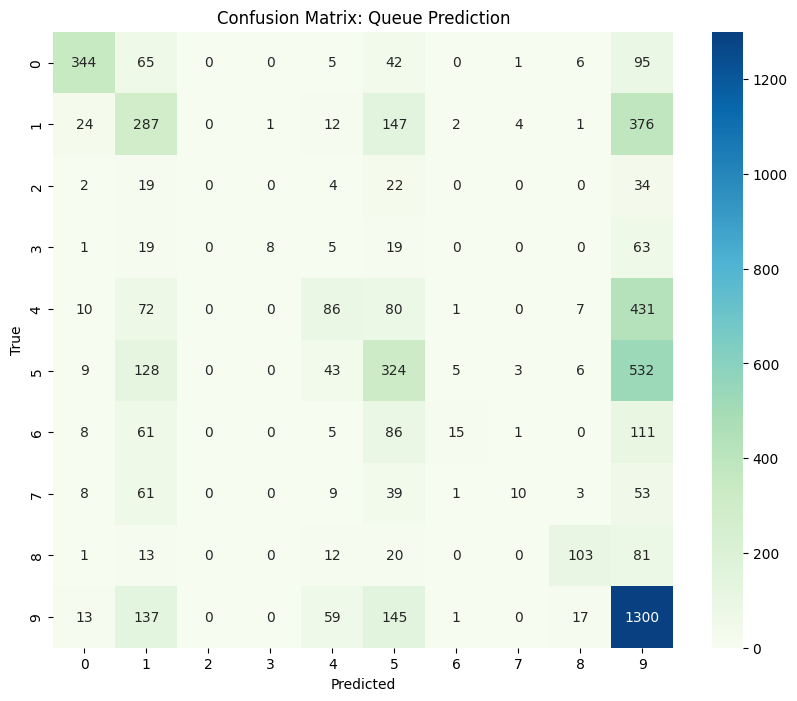

In [16]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu")
plt.title("Confusion Matrix: Queue Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()